# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [2]:
# If needed, uncomment the next line to install dependencies.
%pip install pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Load Data

In [3]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

In [4]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ\"']", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for frame in (df_main, df_fact):
    frame["text_clean"] = frame["sentences"].apply(clean_text)
    frame["n_chars"] = frame["sentences"].astype(str).str.len()
    frame["n_words"] = frame["text_clean"].str.split().str.len()
    frame["n_double_quotes"] = (frame["sentences"].astype(str).str.replace("“", '"', regex=False).str.replace("”", '"', regex=False).str.count('"'))
    frame["n_single_quotes"] = (frame["sentences"].astype(str).str.replace("‘", "'", regex=False).str.replace("’", "'", regex=False).str.count("'"))
    frame["has_quotes"] = ((frame["n_double_quotes"] + frame["n_single_quotes"]) > 0).astype(int)

main_label_map = {-1: "quote", 0: "factual", 1: "biased"}
fact_label_map = {0: "factual", 1: "non_factual"}

df_main["label"] = df_main["classe"].map(main_label_map)
df_fact["label"] = df_fact["classe"].map(fact_label_map)

display(
    df_main[
        ["sentences", "text_clean", "label", "has_quotes"]
    ].head()
)

,sentences,text_clean,label,has_quotes
0,"""Não houve sobreviventes"", disse Okala.","""não houve sobreviventes"" disse okala",quote,1
1,As vítimas do acidente foram 14 passageiros e ...,as vítimas do acidente foram passageiros e trê...,factual,0
2,"O avião explodiu e se incendiou, acrescentou o...",o avião explodiu e se incendiou acrescentou o ...,factual,0
3,"O porta-voz informou que o avião, um Soviet An...",o porta voz informou que o avião um soviet ant...,factual,0
4,"Segundo fontes aeroportuárias, os membros da t...",segundo fontes aeroportuárias os membros da tr...,factual,0


## Exploratory Data Analysis

In [5]:
print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("Task B - Binary factuality label distribution:")
display(df_fact["label"].value_counts().rename_axis("label").reset_index(name="count"))

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


Task B - Binary factuality label distribution:


,label,count
0,factual,4242
1,non_factual,1949


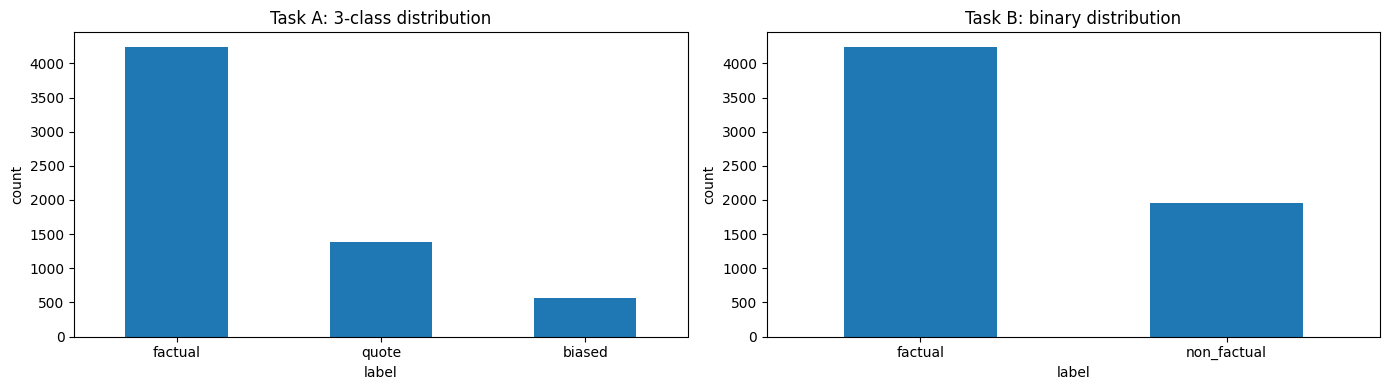

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

df_fact["label"].value_counts().plot(kind="bar", ax=axes[1], title="Task B: binary distribution")
axes[1].set_xlabel("label")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Hugging Face models

## Data Preparation

In [7]:
label_map = {-1: "quote", 0: "factual", 1: "biased"}
id2label  = {0: "biased", 1: "factual", 2: "quote"}
label2id  = {"biased": 0, "factual": 1, "quote": 2}

df_main["label"] = df_main["classe"].map(label_map)
df_main["label_id"] = df_main["label"].map(label2id)


In [8]:
train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

In [9]:
MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Converter para HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

In [12]:
training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,          # GPU no Colab — acelera o treino
    seed=42,
    logging_steps=50,
    report_to="none"    # desativa wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.351801,0.334517,0.693780,0.853025
2,0.268491,0.335186,0.748668,0.874655
3,0.197208,0.381415,0.773039,0.886690


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=930, training_loss=0.30173639584613104, metrics={'train_runtime': 228.7516, 'train_samples_per_second': 64.944, 'train_steps_per_second': 4.066, 'total_flos': 977203233441792.0, 'train_loss': 0.30173639584613104, 'epoch': 3.0})

## Results and Analisys

In [14]:
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values

print(classification_report(
    y_true, y_pred,
    target_names=["biased", "factual", "quote"]
))

              precision    recall  f1-score   support

      biased       0.65      0.37      0.47       112
     factual       0.90      0.96      0.93       849
       quote       0.94      0.90      0.92       278

    accuracy                           0.90      1239
   macro avg       0.83      0.74      0.77      1239
weighted avg       0.89      0.90      0.89      1239

